In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
import torch
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

In [3]:
# import shutil

# shutil.rmtree("/kaggle/working/snakeclef", ignore_errors=True)

In [4]:
# import shutil

# shutil.copytree("/kaggle/input/competitions/snakeclef2022/SnakeCLEF2022-medium_size", "/kaggle/working/snakeclef")

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [6]:
BASE_PATH = "/kaggle/input/competitions/snakeclef2022"

TRAIN_METADATA = BASE_PATH + "/SnakeCLEF2022-TrainMetadata.csv"
TRAIN_IMG_DIR  = BASE_PATH + "/SnakeCLEF2022-medium_size/SnakeCLEF2022-medium_size"

In [7]:
df = pd.read_csv(TRAIN_METADATA)

print("Total samples:", len(df))
print("Total classes:", df["class_id"].nunique())

Total samples: 270251
Total classes: 1572


In [8]:
# =============================================
# FILTER: Indian snake species (via ISO mapping)
# =============================================

ISO_MAPPING = BASE_PATH + "/SnakeCLEF2022-ISOxSpeciesMapping.csv"
iso_df = pd.read_csv(ISO_MAPPING)

# Step 1 — Get all species native to India
india_species = iso_df[iso_df['india'] == 1]['binomial'].tolist()
print(f"Total species native to India: {len(india_species)}")

# Step 2 — Filter FULL TrainMetadata (df from Cell 6, not pre-filtered)
# Re-read to make sure we're using the full dataset
full_df = pd.read_csv(TRAIN_METADATA)
india_df = full_df[full_df['binomial_name'].isin(india_species)]
print(f"Total rows: {len(india_df)}")
print(f"Unique species: {india_df['binomial_name'].nunique()}")

# Step 3 — Keep species with >= 100 images
class_counts = india_df['binomial_name'].value_counts()
top_species = class_counts[(class_counts > 100) & (class_counts < 600)].index
df = india_df[india_df['binomial_name'].isin(top_species)].copy()

print(f"\nAfter >= 100 filter:")
print(f"  Dataset size : {len(df)}")
print(f"  Classes      : {df['binomial_name'].nunique()}")
print()
print(df.groupby('binomial_name').size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
        .to_string(index=False))

Total species native to India: 159
Total rows: 27084
Unique species: 159

After >= 100 filter:
  Dataset size : 13085
  Classes      : 48

               binomial_name  count
    Malayopython reticulatus    599
          Amphiesma stolatum    590
       Fowlea flavipunctatus    583
                Ptyas korros    580
                   Naja naja    579
      Rhabdophis subminiatus    527
        Chrysopelea paradisi    503
           Python bivittatus    476
         Laticauda colubrina    383
Craspedocephalus malabaricus    352
             Daboia russelii    345
          Bungarus fasciatus    337
          Hydrophis platurus    331
       Coelognathus radiatus    331
             Elaphe taeniura    312
             Lycodon aulicus    306
          Ophiophagus hannah    304
             Echis carinatus    289
        Dendrelaphis tristis    277
         Xenopeltis unicolor    264
       Gonyosoma oxycephalum    260
  Craspedocephalus gramineus    259
              Python molurus    2

### Train/Validation Split

In [9]:
train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["class_id"],
    random_state=42
)

### Fix Labels

In [10]:
unique_classes = sorted(train_df["class_id"].unique())

class_to_idx = {cls: idx for idx, cls in enumerate(unique_classes)}

train_df["class_id"] = train_df["class_id"].map(class_to_idx)
val_df["class_id"]   = val_df["class_id"].map(class_to_idx)

num_classes = len(unique_classes)

print("Num classes:", num_classes)

Num classes: 48


### Transforms

In [11]:
train_transform = transforms.Compose([
    transforms.Resize((518,518)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2,0.2,0.2,0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((518,518)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

### Dataset Class

In [12]:
Image.LOAD_TRUNCATED_IMAGES = True

class SnakeDataset(Dataset):

    def __init__(self, df, root_dir, transform=None):
        self.df = df
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        try:
            img_path = os.path.join(
                self.root_dir,
                self.df.iloc[idx]["file_path"]
            )
            image = Image.open(img_path).convert("RGB")
        except:
            return self.__getitem__((idx+1) % len(self.df))

        label = self.df.iloc[idx]["class_id"]

        if self.transform:
            image = self.transform(image)

        return image, label

### DataLoaders

In [13]:
train_dataset = SnakeDataset(train_df, TRAIN_IMG_DIR, train_transform)
val_dataset   = SnakeDataset(val_df, TRAIN_IMG_DIR, val_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)

# Model

In [14]:
# print("Available Vision Transformer Models: ")
# timm.list_models("vit*")

In [15]:
model = timm.create_model(
    "vit_large_patch14_dinov2",
    pretrained=True,
    num_classes=num_classes
)

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = torch.nn.DataParallel(model)

model = model.to(device)

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Using 2 GPUs!


In [16]:
for param in model.parameters():
    param.requires_grad = False

for param in model.module.head.parameters():
    param.requires_grad = True

### Loss + Optimizer

In [17]:
criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

scaler = torch.amp.GradScaler("cuda")

In [18]:
# import os

# def file_exists(row):
#     path = os.path.join(TRAIN_IMG_DIR, row["file_path"])
#     return os.path.exists(path)

# df = df[df.apply(file_exists, axis=1)]

# print("After filtering:", len(df))

In [19]:
def save_checkpoint(epoch, batch_idx, model, optimizer, scheduler, best_acc):
    torch.save({
        "epoch": epoch,
        "batch_idx": batch_idx,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_acc": best_acc
    }, "/kaggle/working/checkpoint.pth")

In [20]:
start_epoch = 0
start_batch = 0
best_acc = 0

if os.path.exists("/kaggle/working/checkpoint.pth"):
    checkpoint = torch.load("/kaggle/working/checkpoint.pth",weights_only=False)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    scheduler.load_state_dict(checkpoint["scheduler_state"])

    start_epoch = checkpoint["epoch"]
    start_batch = checkpoint["batch_idx"]
    best_acc = checkpoint["best_acc"]

    print(f"Resuming from epoch {start_epoch}, batch {start_batch}")

### Training Loop

In [21]:
train_losses = []
val_losses = []
val_accs = []

# =========================
# FREEZE BACKBONE INITIALLY
# =========================
for param in model.parameters():
    param.requires_grad = False

for param in model.module.head.parameters():
    param.requires_grad = True

# =========================
# OPTIMIZER + SCHEDULER
# =========================
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=12
)

# =========================
# TRAINING LOOP
# =========================
for epoch in range(start_epoch, 12):

    # Unfreeze after 3 epochs
    if epoch == 3:
        for param in model.parameters():
            param.requires_grad = True
        print("Backbone unfrozen")

    model.train()
    running_loss = 0

    for batch_idx, (images, labels) in enumerate(train_loader):

        # Resume support
        if epoch == start_epoch and batch_idx < start_batch:
            continue

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        if batch_idx % 500 == 0 and batch_idx != 0:
            save_checkpoint(epoch, batch_idx, model, optimizer, scheduler, best_acc)
            print(f"Checkpoint saved at batch {batch_idx}")

        if batch_idx % 100 == 0:
            print(f"Epoch {epoch+1} | Batch {batch_idx}/{len(train_loader)} | Loss {loss.item():.4f}")

    scheduler.step()

    num_batches_trained = batch_idx + 1 - (start_batch if epoch == start_epoch else 0)
    epoch_loss = running_loss / num_batches_trained
    train_losses.append(epoch_loss)

    # =========================
    # VALIDATION
    # =========================
    model.eval()

    all_preds = []
    all_targets = []
    all_probs = []
    val_running_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            val_loss = criterion(outputs, labels)
            val_running_loss += val_loss.item()

            prob = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())
            all_probs.extend(prob.cpu().numpy())

    acc = (np.array(all_preds) == np.array(all_targets)).mean()
    val_epoch_loss = val_running_loss / len(val_loader)
    val_accs.append(acc)
    val_losses.append(val_epoch_loss)

    print(f"\nEpoch {epoch+1} Completed")
    print(f"  Train Loss : {epoch_loss:.4f}")
    print(f"  Val Loss   : {val_epoch_loss:.4f}")
    print(f"  Val Acc    : {acc:.4f}\n")

    # =========================
    # SAVE BEST MODEL
    # =========================
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "/kaggle/working/best_model.pth")
        print("Best model saved!")

    # =========================
    # SAVE END-OF-EPOCH CHECKPOINT
    # =========================
    save_checkpoint(epoch, len(train_loader), model, optimizer, scheduler, best_acc)

Epoch 1 | Batch 0/1391 | Loss 4.2884
Epoch 1 | Batch 100/1391 | Loss 3.9500
Epoch 1 | Batch 200/1391 | Loss 3.0482
Epoch 1 | Batch 300/1391 | Loss 3.0435
Epoch 1 | Batch 400/1391 | Loss 3.3309
Checkpoint saved at batch 500
Epoch 1 | Batch 500/1391 | Loss 2.4941
Epoch 1 | Batch 600/1391 | Loss 2.7853
Epoch 1 | Batch 700/1391 | Loss 2.7008
Epoch 1 | Batch 800/1391 | Loss 2.6981
Epoch 1 | Batch 900/1391 | Loss 2.3806
Checkpoint saved at batch 1000
Epoch 1 | Batch 1000/1391 | Loss 2.1526
Epoch 1 | Batch 1100/1391 | Loss 2.5923
Epoch 1 | Batch 1200/1391 | Loss 2.6194
Epoch 1 | Batch 1300/1391 | Loss 2.4600

Epoch 1 Completed
  Train Loss : 2.8296
  Val Loss   : 2.0882
  Val Acc    : 0.5772

Best model saved!
Epoch 2 | Batch 0/1391 | Loss 2.5890
Epoch 2 | Batch 100/1391 | Loss 1.7055
Epoch 2 | Batch 200/1391 | Loss 1.8926
Epoch 2 | Batch 300/1391 | Loss 2.3881
Epoch 2 | Batch 400/1391 | Loss 2.0453
Checkpoint saved at batch 500
Epoch 2 | Batch 500/1391 | Loss 1.3547
Epoch 2 | Batch 600/1391 

# Save Model

In [22]:
torch.save(model.state_dict(), "/kaggle/working/snake_model.pth")

# Visualization Curves

### Classification Report

In [23]:
from sklearn.metrics import classification_report

print(classification_report(all_targets, all_preds))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        17
           1       0.79      0.86      0.83        22
           2       0.93      0.74      0.82        19
           3       0.99      0.94      0.97        88
           4       0.89      0.97      0.93        35
           5       0.86      0.93      0.89        27
           6       0.96      0.96      0.96        51
           7       0.95      0.96      0.95        75
           8       1.00      0.88      0.94        25
           9       0.87      0.94      0.90        35
          10       0.98      0.98      0.98        50
          11       1.00      0.97      0.99        39
          12       0.98      1.00      0.99        53
          13       0.96      0.92      0.94        52
          14       1.00      0.98      0.99        42
          15       0.98      1.00      0.99        43
          16       0.90      0.98      0.94        47
          17       0.87    

### Confusion Matrix

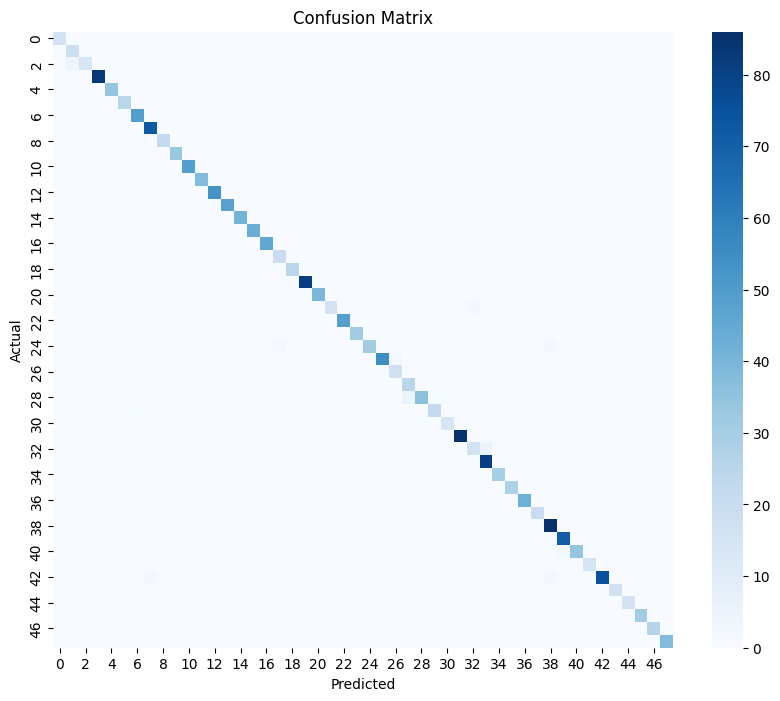

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### ROC Curve

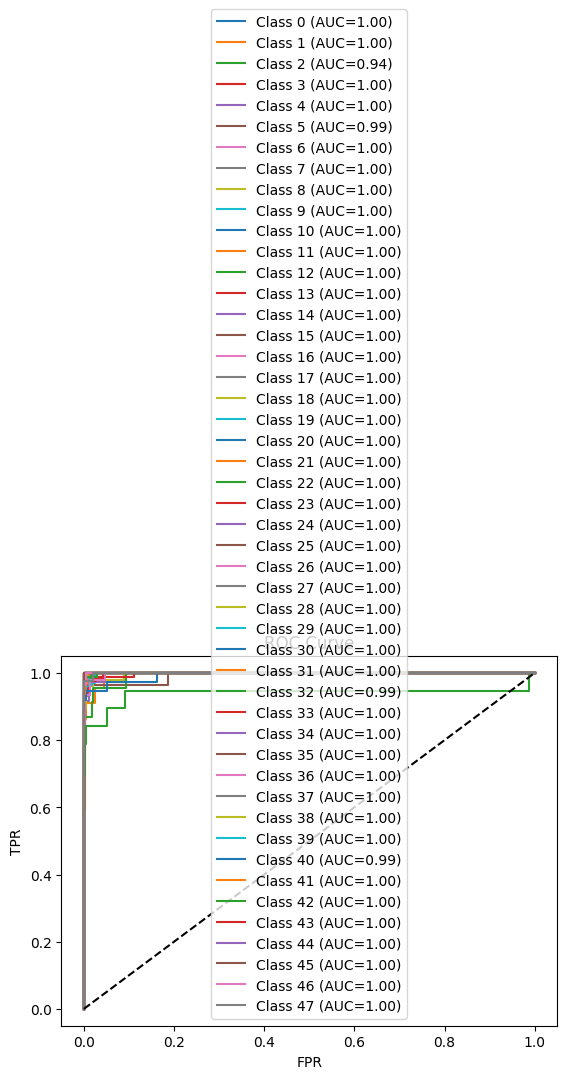

In [25]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

n_classes = len(set(all_targets))

y_true_bin = label_binarize(all_targets, classes=range(n_classes))
y_score = np.array(all_probs)

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

### Learning Curve

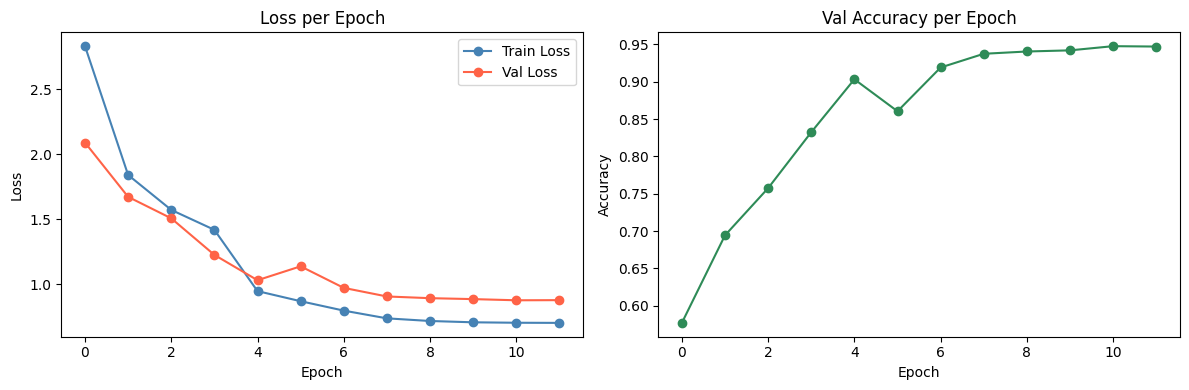

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, marker='o', color='steelblue', label='Train Loss')
ax1.plot(val_losses, marker='o', color='tomato', label='Val Loss')
ax1.set_title("Loss per Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(val_accs, marker='o', color='seagreen')
ax2.set_title("Val Accuracy per Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

### Confidence Score Distribution

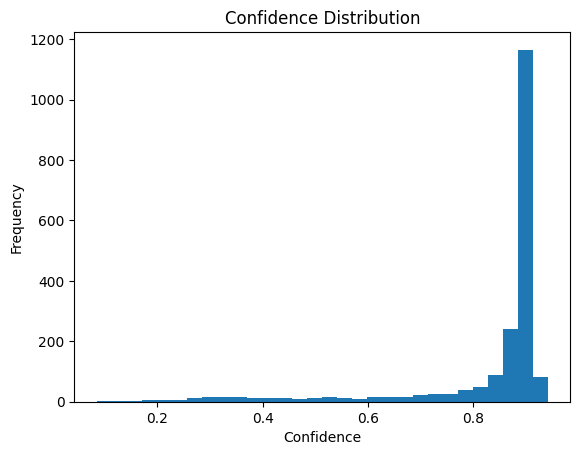

In [27]:
confidences = np.max(all_probs, axis=1)

plt.hist(confidences, bins=30)
plt.title("Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()

### False-Positive / False-Negative Visualization

### Correlation Matrix

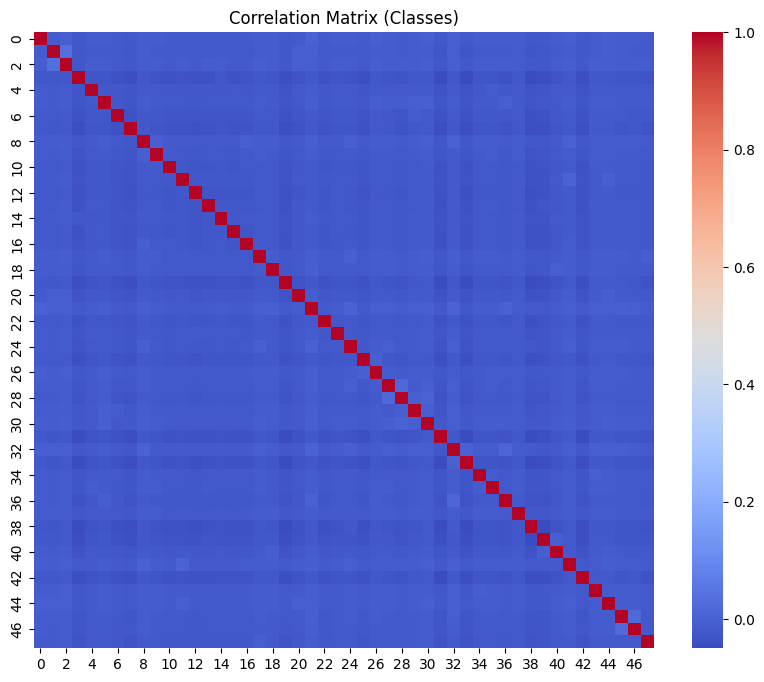

In [28]:
corr = np.corrcoef(np.array(all_probs).T)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix (Classes)")
plt.show()

### Class Activation Map

In [29]:
import torch.nn.functional as F

def show_cam(model, image, label):

    model.eval()
    image = image.unsqueeze(0).to(device)

    features = []

    def hook(module, input, output):
        features.append(output)

    handle = model.features[-1].register_forward_hook(hook)

    output = model(image)
    pred = output.argmax(dim=1)

    feature_map = features[0][0].detach().cpu()

    heatmap = torch.mean(feature_map, dim=0)
    heatmap = F.relu(heatmap)
    heatmap /= heatmap.max()

    plt.imshow(heatmap, cmap='jet')
    plt.title(f"CAM | Pred: {pred.item()} | True: {label}")
    plt.show()

    handle.remove()

### Precision vs Recall Curve

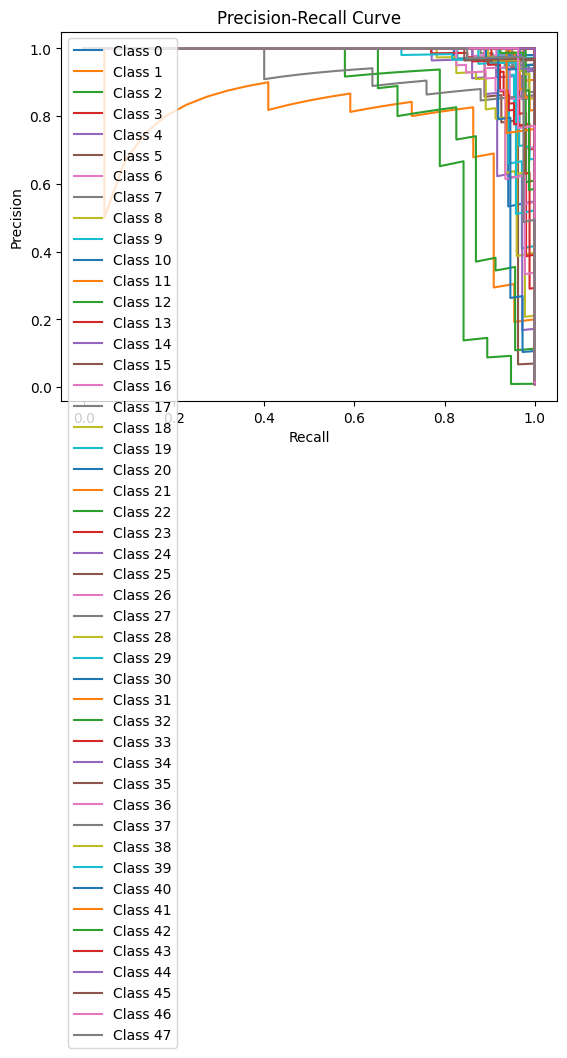

In [30]:
from sklearn.metrics import precision_recall_curve

precision = dict()
recall = dict()

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(
        y_true_bin[:, i], y_score[:, i]
    )
    plt.plot(recall[i], precision[i], label=f"Class {i}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()